<a href="https://colab.research.google.com/github/maury20/ia-grafos-Mauriane-Caldas-da-Silva/blob/main/ia_grafos_Mauriane_Caldas_da_Silva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lista de Exercícios N2 - Grafos e Algoritmos de Busca**

Tema: Grafos e Algoritmos de Busca (Dijkstra, A*, em-ordem, pré-ordem e pós-ordem)

Disciplina: Inteligência Artificial

Matricula:[2401916]

Nome: [MAURIANE CALDAS DA SILVA]

Turma: [ENGCO221N01]

GitHub: [https://github.com/maury20/ia-grafos-Mauriane-Caldas-da-Silva.git]

**Parte A — Algoritmo de Dijkstra**

**Implementação do Algoritmo de Dijkstra**

In [ ]:
import heapq
from collections import defaultdict

def dijkstra(graph, start):

    # Define distâncias iniciais como infinito e rastreia o nó anterior.
    dist = {v: float('inf') for v in graph}
    parent = {v: None for v in graph}
    dist[start] = 0

    # Cria uma fila de prioridade para extrair o caminho mais curto.
    pq = [(0, start)]

    while pq:
        current_dist, u = heapq.heappop(pq)

        # Ignora se já encontramos um caminho mais curto para este nó.
        if current_dist > dist[u]:
            continue

        # Examina vizinhos para tentar reduzir a distância total ou atualiza as distâncias dos nós vizinhos.
        for neighbor, weight in graph[u]:
            distance = current_dist + weight

            if distance < dist[neighbor]:
                dist[neighbor] = distance
                parent[neighbor] = u
                heapq.heappush(pq, (distance, neighbor))

    return dist, parent

def reconstruct_path(parent, target):

    path = []
    current = target

    while target is not None:
        path.append(target)
        target = parent[target]
    return path[::-1]  #Inverte a lista para exibir o caminho na ordem correta (início -> fim).


# Define o mapa das ruas com os tempos de viagem em minutos entre os pontos.
graph = {

    'Hospital': [('A', 6), ('B', 4)],
    'A': [('Hospital', 5), ('C', 3), ('D', 7)],
    'B': [('Hospital', 3), ('C', 1), ('E', 4)],
    'C': [('A', 5), ('B', 1), ('D', 2), ('E', 3)],
    'D': [('A', 5), ('C', 2), ('Destino', 7)],
    'E': [('B', 1), ('C', 1), ('Destino', 4)],
    'Destino': [('D', 6), ('E', 3)]
}

start = 'Hospital'
target = 'Destino'

dist, parent = dijkstra(graph, start)
path = reconstruct_path(parent, target)

print("Custo mínimo até cada ponto:")
for node, d in dist.items():
    print(f"{node}: {d} minutos")

print("\nCaminho mais rápido do Hospital até o Destino:")
print(" → ".join(path))


Custo mínimo até cada ponto:
Hospital: 0 minutos
A: 6 minutos
B: 4 minutos
C: 5 minutos
D: 7 minutos
E: 8 minutos
Destino: 12 minutos

Caminho mais rápido do Hospital até o Destino:
Hospital → B → E → Destino


**1. Por que Dijkstra exige arestas não negativas?**


O Dijkstra baseia-se na ideia de que, ao remover um nó da fila de prioridade, a menor distância até ele já foi determinada de forma definitiva. Se houver arestas com pesos negativos, esse princípio deixa de ser válido, pois um caminho que inicialmente parecia mais longo pode se tornar mais curto ao incluir uma aresta negativa depois. Isso comprometeria a precisão do algoritmo e ele deixaria de produzir resultados corretos.

**2. Qual a complexidade do algoritmo com lista de adjacência e heapq?**

A complexidade do Dijkstra é O((V + E) log V), sendo V o total de vértices e E o número de arestas do grafo. Cada vértice é inserido e removido da fila de prioridade com custo logarítmico, e cada aresta é analisada uma única vez. Graças ao uso da estrutura de heap binária (heapq), as operações de atualização e extração são eficientes, resultando em um desempenho adequado mesmo em grafos grandes.

**Parte B — Algoritmo A**

**Implementação do Algoritmo A**

Mapa gerado (0 = livre, 1 = obstáculo):
[[0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 1 1 0 0 0 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1]
 [0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0]]

Caminho encontrado! Custo total: 38
Tamanho do caminho: 39 posições


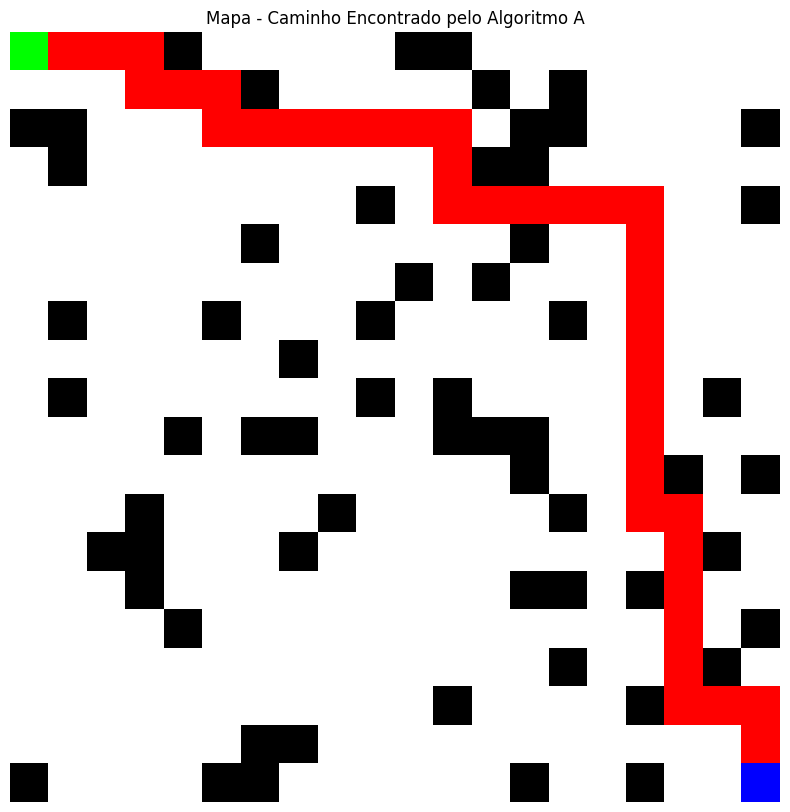

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from heapq import heappush, heappop

def generate_grid(size=20, obstacle_prob=0.15):

    # Sorteia posições de obstáculos com base na probabilidade
    grid = np.random.choice([0, 1], size=(size, size), p=[1 - obstacle_prob, obstacle_prob])

    # Garante que o ponto inicial e final estejam livres
    grid[0, 0] = 0
    grid[-1, -1] = 0

    return grid

def manhattan_distance(a, b):

    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def a_star(grid, start, goal, heuristic):

    rows, cols = grid.shape

    # Verifica se início ou destino estão bloqueados
    if grid[start] == 1 or grid[goal] == 1:
        return None, float('inf')

    # Estruturas de dados usadas no A*
    open_set = []
    heappush(open_set, (0, start))# adiciona o nó inicial com custo 0
    came_from = {}
    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}# custo total estimado (g + h)

    # Movimentos válidos (cima, baixo, esquerda, direita)
    directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]

    # Loop principal do A*
    while open_set:
        _, current = heappop(open_set)

        # Se o destino for alcançado, reconstrói o trajeto
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1], g_score[goal]  # inverte o caminho

        # Explora vizinhos do nó atual
        for dx, dy in directions:
            neighbor = (current[0] + dx, current[1] + dy)

            # Ignora posições fora dos limites ou bloqueadas
            if not (0 <= neighbor[0] < rows and 0 <= neighbor[1] < cols):
                continue
            if grid[neighbor] == 1:
                continue

            # Calcula o custo acumulado até o vizinho
            tentative_g = g_score[current] + 1

            # Se for um caminho melhor, atualiza as estruturas
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score[neighbor] = tentative_g + heuristic(neighbor, goal)
                heappush(open_set, (f_score[neighbor], neighbor))

    # Se não há caminho viável, retorna infinito
    return None, float('inf')

def visualize_grid(grid, path=None):

    plt.figure(figsize=(10, 10))
    visual = np.zeros((grid.shape[0], grid.shape[1], 3))

    # Define as cores básicas
    visual[grid == 1] = [0, 0, 0]# obstáculos
    visual[grid == 0] = [1, 1, 1]# caminho livre

    # Se o caminho foi encontrado, destaca-o
    if path:
        for pos in path:
            visual[pos] = [1, 0, 0]  # vermelho
        visual[path[0]] = [0, 1, 0]  # início (verde)
        visual[path[-1]] = [0, 0, 1]  # destino (azul)

    plt.imshow(visual)
    plt.title("Mapa - Caminho Encontrado pelo Algoritmo A")
    plt.axis("off")
    plt.show()

# ALGORITMO
grid = generate_grid(20, 0.15)
start = (0, 0)
goal = (19, 19)

print("Mapa gerado (0 = livre, 1 = obstáculo):")
print(grid)

path, cost = a_star(grid, start, goal, manhattan_distance)

# Exibe o resultado
if path:
    print(f"\nCaminho encontrado! Custo total: {cost}")
    print(f"Tamanho do caminho: {len(path)} posições")
    visualize_grid(grid, path)
else:
    print("\nNenhuma rota possível encontrada!")
    visualize_grid(grid)




**Questões Discursivas - Parte B**

**1. A vs Dijkstra: qual expande menos nós?**

O A* geralmente expande menos nós que o Dijkstra porque usa uma heurística para guiar a busca em direção ao objetivo. Enquanto o Dijkstra explora igualmente em todas as direções, o A* prioriza nós que parecem estar mais próximos do destino, tornando-o mais eficiente em problemas onde uma boa heurística está disponível.

**2. Por que a heurística Manhattan é admissível nesse caso?**

A distância Manhattan é admissível neste contexto porque em um grid com movimentação nas 4 direções (cima, baixo, esquerda, direita), ela nunca superestima o custo real. O custo mínimo entre dois pontos em tal grid é exatamente a distância Manhattan, já que cada movimento tem custo 1 e não é possível "cortar caminho" na diagonal.

**Parte C — Árvores Binárias e Percursos**

**Implementação da BST e Percursos**

In [ ]:
class Node:

    #Nó de uma árvore binária
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

class BST: #Árvore Binária de Busca
    def __init__(self):
        self.root = None

    def insert(self, value): #Insere um valor na BST

        if self.root is None:
            self.root = Node(value)
        else:
            self._insert_recursive(self.root, value)

    def _insert_recursive(self, node, value):
        if value < node.value:
            if node.left is None:
                node.left = Node(value)
            else:
                self._insert_recursive(node.left, value)
        else:
            if node.right is None:
                node.right = Node(value)
            else:
                self._insert_recursive(node.right, value)

def in_order(node, result=None): #Percurso em ordem: esquerda → raiz → direita

    if result is None:
        result = []
    if node:
        in_order(node.left, result)
        result.append(node.value)
        in_order(node.right, result)
    return result


def pre_order(node, result=None):  #Percurso pré-ordem: raiz → esquerda → direita

    if result is None:
        result = []
    if node:
        result.append(node.value)
        pre_order(node.left, result)
        pre_order(node.right, result)
    return result


def post_order(node, result=None):#Percurso pós-ordem: esquerda → direita → raiz

    if result is None:
        result = []
    if node:
        post_order(node.left, result)
        post_order(node.right, result)
        result.append(node.value)
    return result

 # Cria a BST com os valores fornecidos
values = [50, 30, 70, 20, 40, 60, 80, 35, 45]
bst = BST()

for value in values:
    bst.insert(value)

# Executa os percursos
print("Valores inseridos:", values)
print("\nPercurso Em-Ordem  :", in_order(bst.root))
print("Percurso Pré-Ordem :", pre_order(bst.root))
print("Percurso Pós-Ordem :", post_order(bst.root))

# Verificação esperada
print("\n--- Verificação Esperada ---")
print("Em-ordem esperado : [20, 30, 35, 40, 45, 50, 60, 70, 80]")
print("Pré-ordem esperado: [50, 30, 20, 40, 35, 45, 70, 60, 80]")
print("Pós-ordem esperado: [20, 35, 45, 40, 30, 60, 80, 70, 50]")


Valores inseridos: [50, 30, 70, 20, 40, 60, 80, 35, 45]

Percurso Em-Ordem  : [20, 30, 35, 40, 45, 50, 60, 70, 80]
Percurso Pré-Ordem : [50, 30, 20, 40, 35, 45, 70, 60, 80]
Percurso Pós-Ordem : [20, 35, 45, 40, 30, 60, 80, 70, 50]

--- Verificação Esperada ---
Em-ordem esperado : [20, 30, 35, 40, 45, 50, 60, 70, 80]
Pré-ordem esperado: [50, 30, 20, 40, 35, 45, 70, 60, 80]
Pós-ordem esperado: [20, 35, 45, 40, 30, 60, 80, 70, 50]


**Questões Discursivas - Parte C**

**1. Em que situação cada tipo de percurso é mais indicado?**

· Em-ordem: Ideal para obter elementos em ordem crescente em Árvores Binárias de Busca (BSTs), útil para gerar relatórios ordenados, estatísticas ou quando se precisa processar dados de forma sequencial.

· Pré-ordem: Útil para copiar/reconstruir árvores e para serialização. Também é indicado quando se precisa processar a raiz antes das subárvores, como na representação de expressões matemáticas.

·Pós-ordem: Adequado para operações que requerem processar os nós filhos antes dos pais, como a liberação de memória (destruição) da árvore ou a avaliação de expressões pós-fixadas.

**Parte D — Reflexões**


**1. Quando não é vantajoso usar A, mesmo tendo uma heurística?**

O A* pode não ser vantajoso em situações onde o espaço de busca é pequeno, tornando o overhead da heurística maior que o benefício, quando a heurística é computacionalmente cara, em ambientes dinâmicos com custos das arestas variáveis, quando há limitação de memória, ou quando não é necessária a solução ótima, sendo preferível usar algoritmos mais rápidos como Best-First Search.


**2. Diferencie corretude e otimalidade nos algoritmos estudados.**

Corretude significa que o algoritmo sempre encontra uma solução válida quando ela existe e nunca retorna resultados incorretos, enquanto otimalidade garante que a solução encontrada é a melhor possível, ou seja, de menor custo. Dijkstra e A* são ambos corretos e ótimos em grafos com pesos não-negativos, mas um algoritmo pode ser correto sem ser ótimo, embora não possa ser ótimo sem ser correto.

**3. Dê um exemplo do mundo real onde cada tipo de percurso (em, pré, pós) é essencial.**

O percurso em-ordem é usado para listar produtos por preço em um sistema de recomendação, do mais barato ao mais caro; o percurso pré-ordem é útil para clonar hierarquias organizacionais, garantindo que o nó pai seja processado antes dos filhos; e o percurso pós-ordem é importante para cálculos como orçamentos de projetos, somando primeiro os custos das sub-tarefas antes do projeto principal.

**4. Como heurísticas inconsistentes podem afetar o resultado do A ?**

Heurísticas inconsistentes podem levar à reexpansão de nós, aumentando significativamente o tempo de execução e reduzindo a eficiência do A*, embora ainda retornem o caminho ótimo se forem admissíveis; heurísticas consistentes, por outro lado, garantem que cada nó seja expandido apenas uma vez, otimizando a performance e evitando retrabalho.

